# Import functions

In [100]:
%run "..\Model\DataHelpers.ipynb"

import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import numpy as np
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
import seaborn as sns

# SHAP
import shap

class_names = ['nTNBC', 'TNBC']

targetGenes = ['CD1A', 'CSF2RB', 'EPCAM', 'ERBB2', 'ESR1', 'EZH2', 'FGB', 'FOXA1',
       'FOXC1', 'GATA3', 'LAMA2', 'LMNA', 'MDGA2', 'OBSCN', 'OGN', 'PGR',
       'SELL', 'SRC', 'TACSTD2', 'TBC1D22B', 'TFF1', 'TGFB3', 'UBE2C', 'VTCN1',
       'WTAP', 'YES1', 'YOD1']

# Preliminary by SHAP
shap.initjs() # necessary for visualization

# Load Dataset

In [101]:
import pandas as pd

# patient_genes_literature
FILE_PATH = "../Data/patient_genes_lasso.csv" # Can be replaced with desired variant for different feature sets
df = pd.read_csv(FILE_PATH)

# Split DataSet

In [102]:
X, y, X_train, X_test, y_train, y_test, test_case_id = split_data(df, "tnbc", "case_id")

X_train.shape=(781, 27)
X_test.shape=(196, 27)
y_train.shape=(781,)
y_test.shape=(196,)


# Stratified set of 100 cases as per best practice SHAP

In [103]:
X_stratified, _, y_stratified, _ = train_test_split(
    X_train, y_train,
    train_size=100,
    stratify=y_train,
    random_state=42
)

X_stratified.shape

(100, 27)

# Get Explainers for each algorithm

*** - Applying SVM to LIME - Start


  0%|          | 0/196 [00:00<?, ?it/s]

**********************************
*** DIT IS aantal -- 3
**********************************


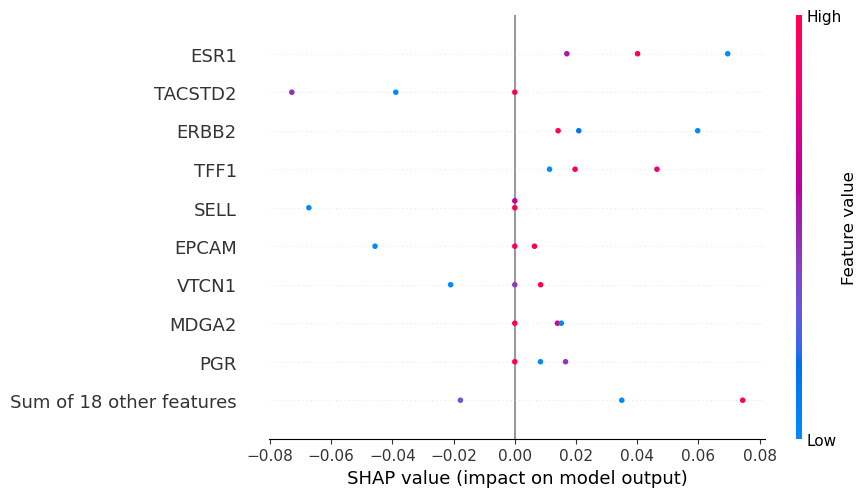

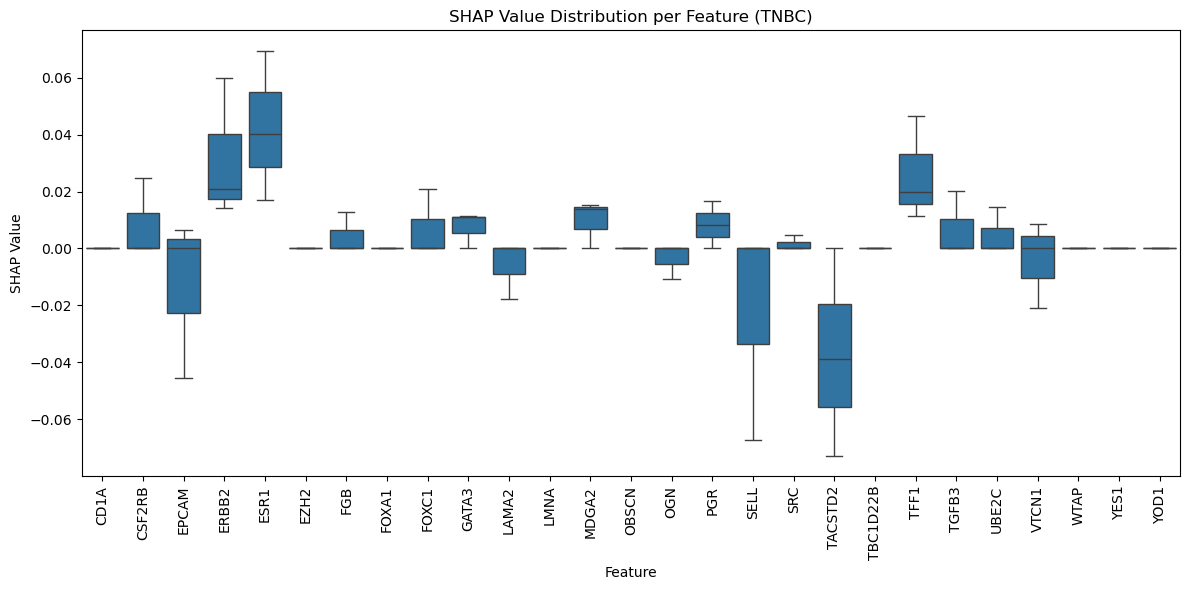

**********************************
*** DIT IS aantal -- 7
**********************************


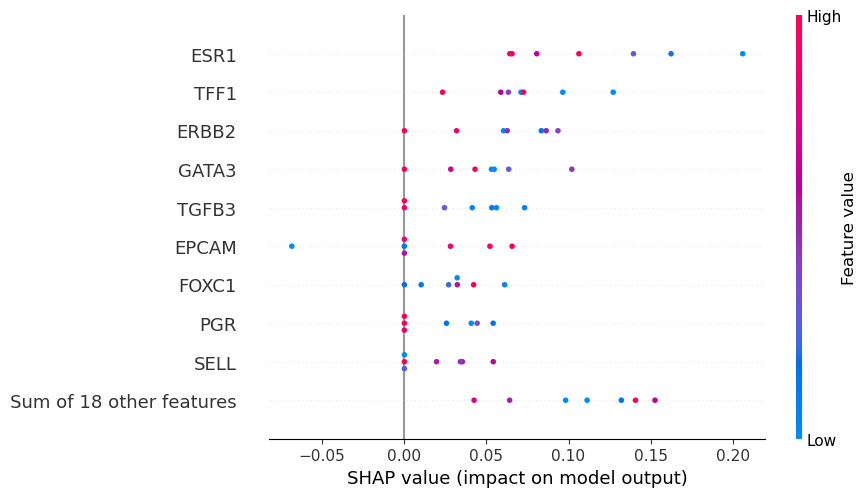

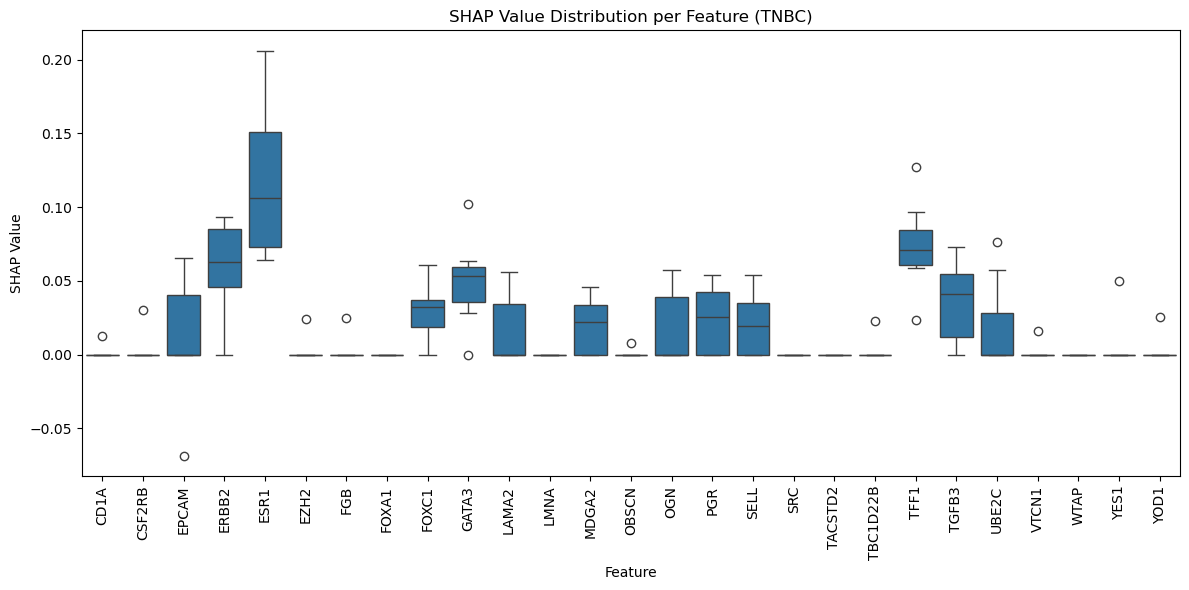

**********************************
*** DIT IS aantal -- 20
**********************************


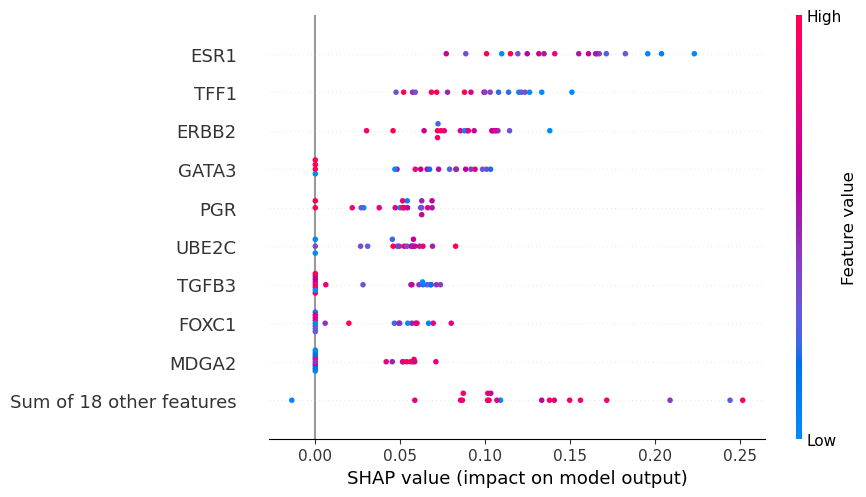

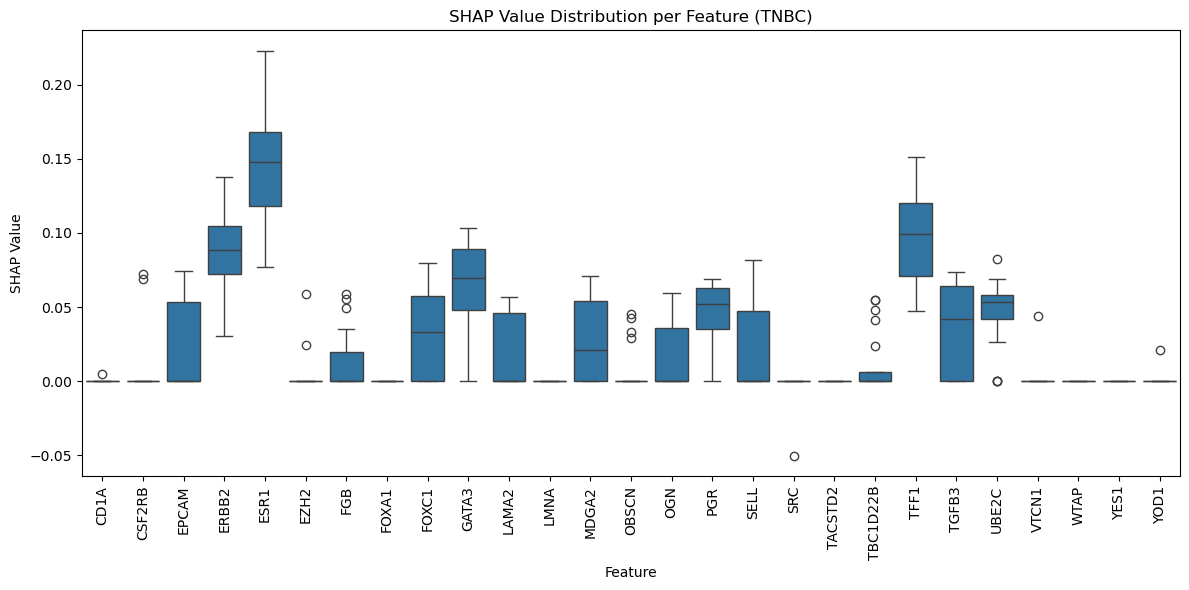

**********************************
*** DIT IS aantal -- 166
**********************************


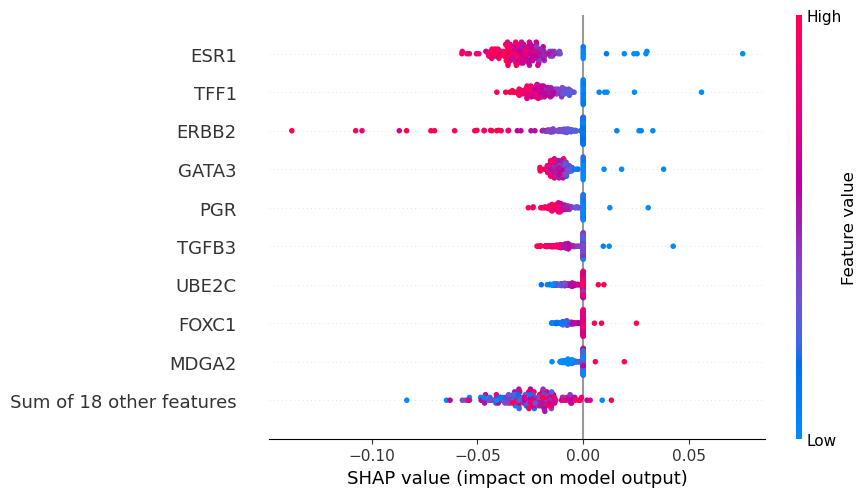

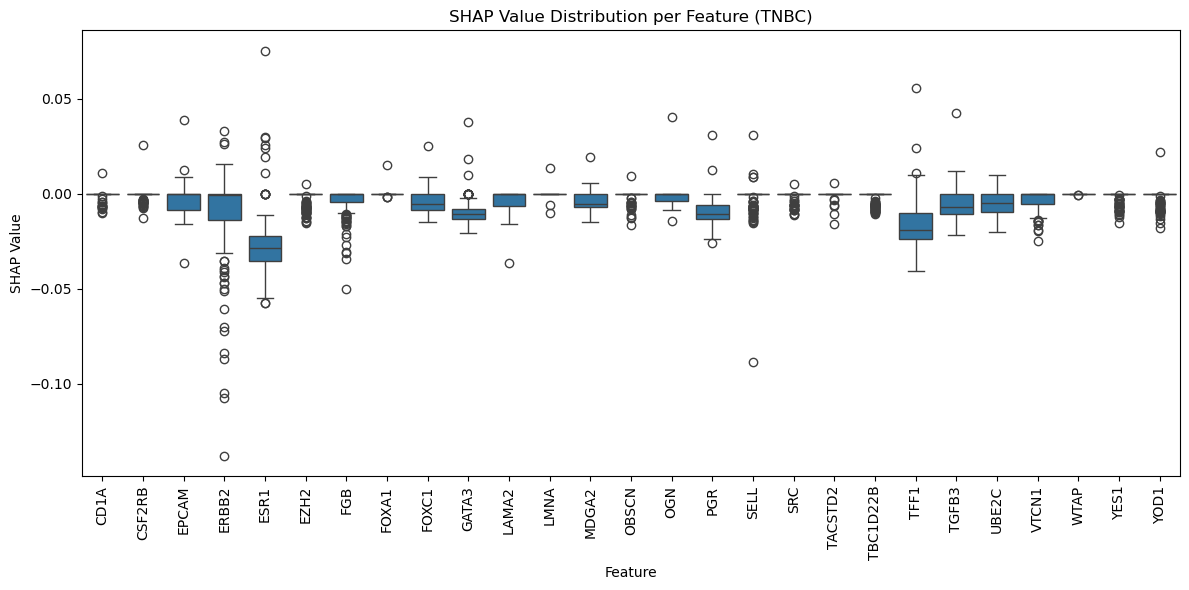

*** - Applying RF to LIME - Start
**********************************
*** DIT IS aantal -- 1
**********************************


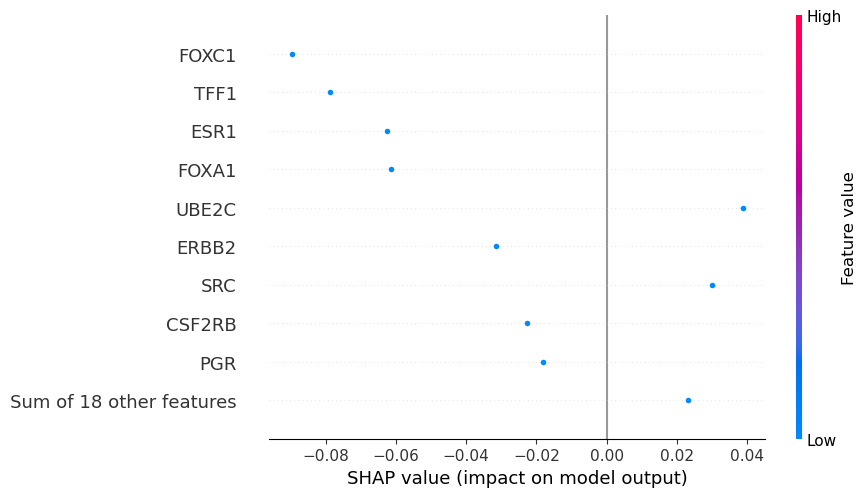

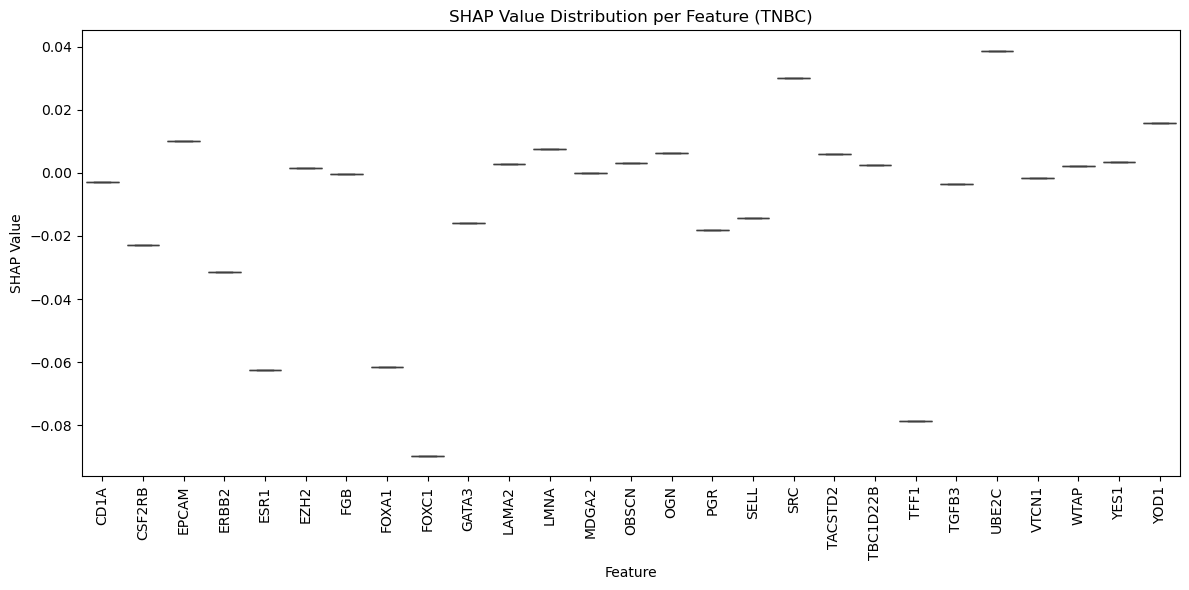

**********************************
*** DIT IS aantal -- 7
**********************************


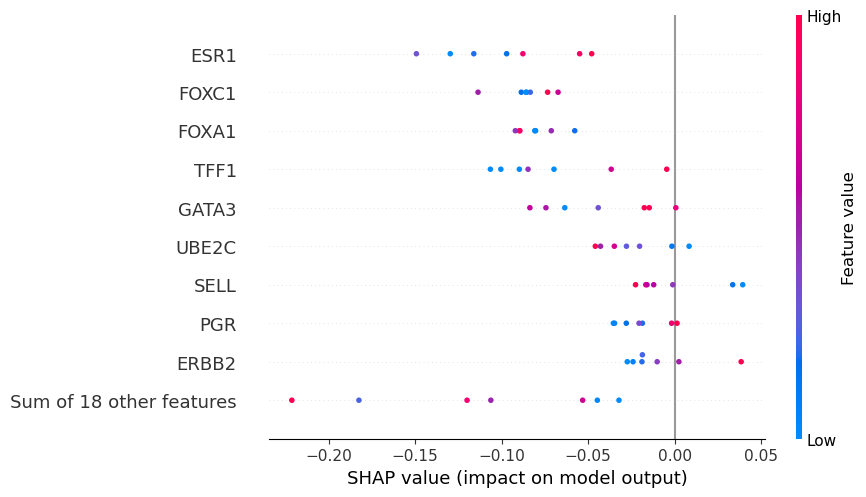

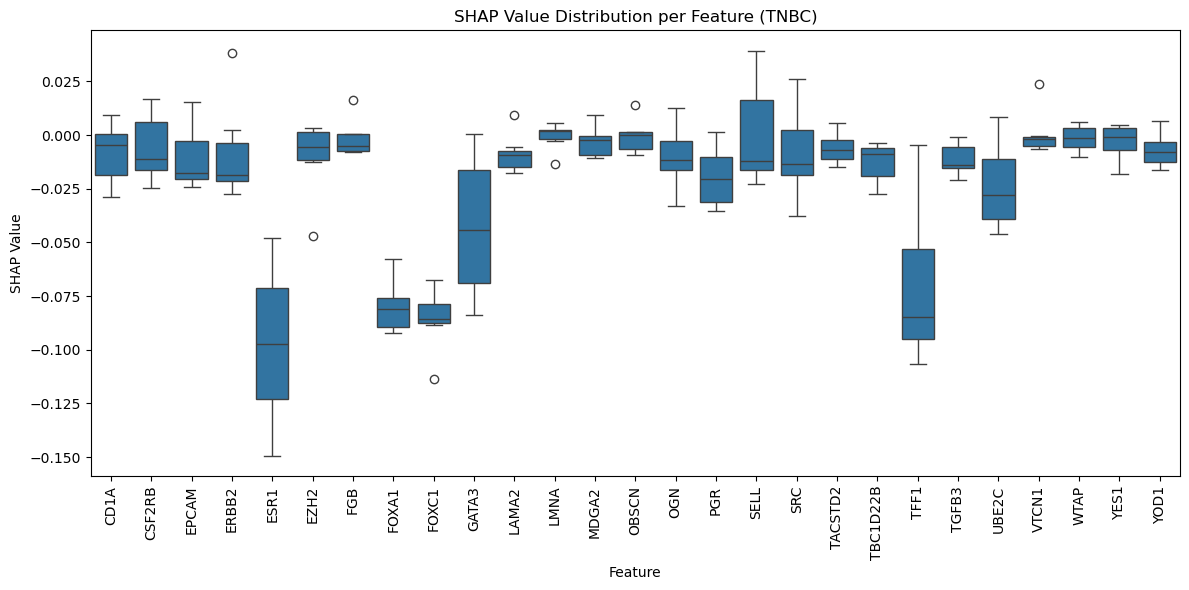

**********************************
*** DIT IS aantal -- 22
**********************************


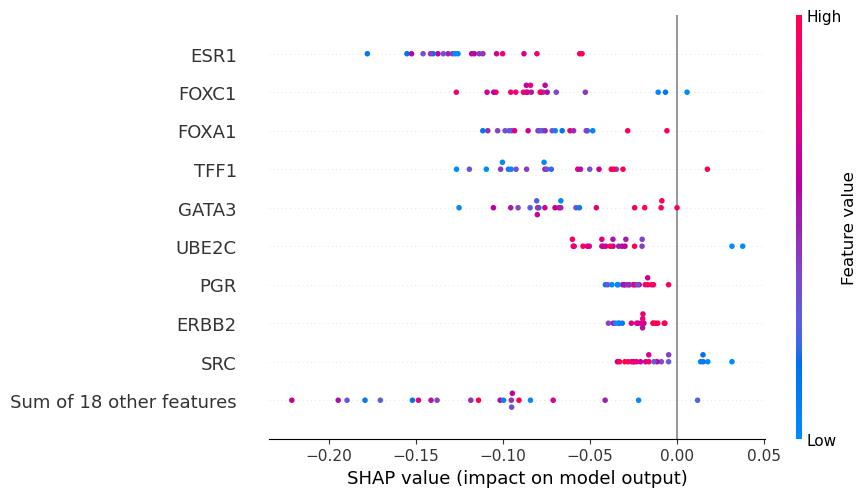

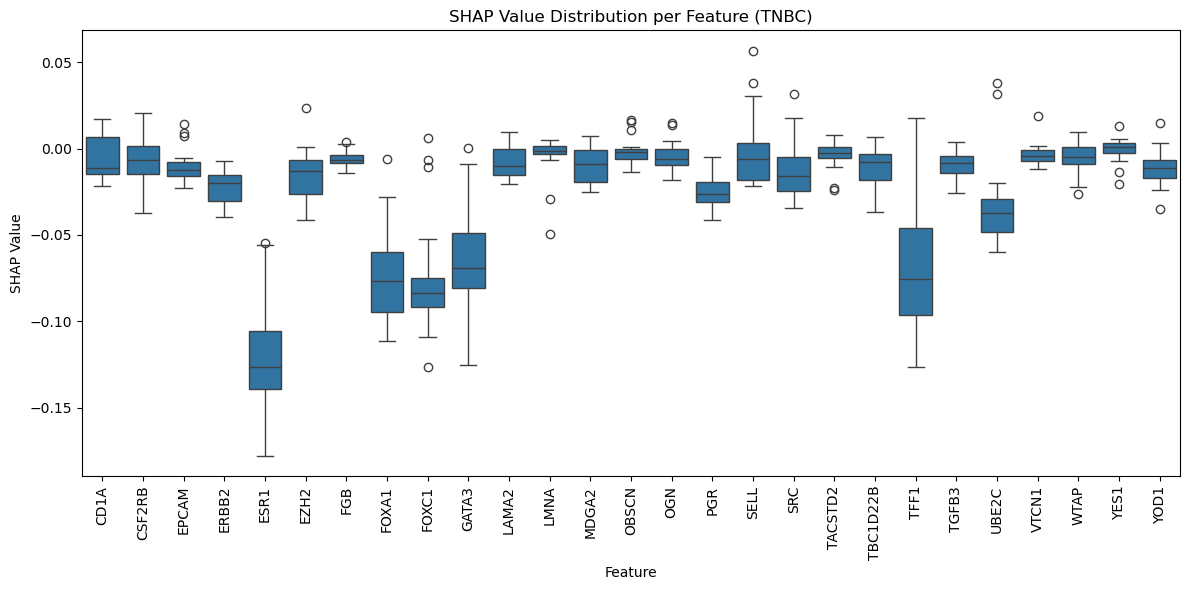

**********************************
*** DIT IS aantal -- 166
**********************************


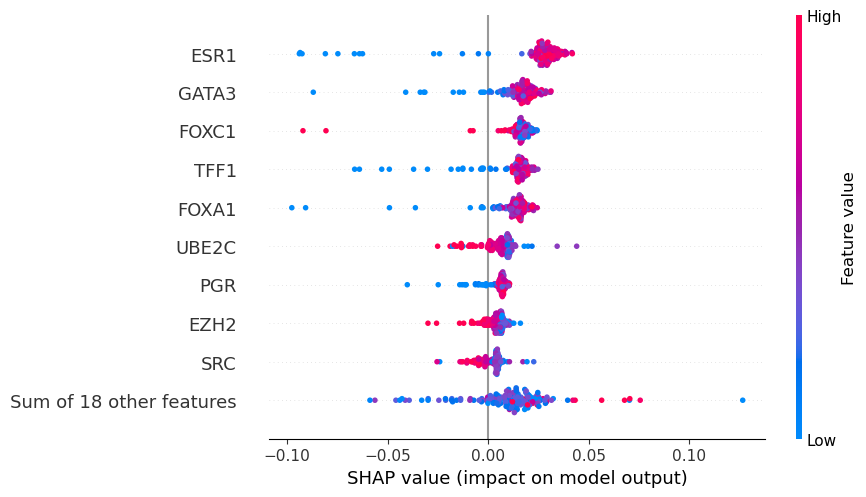

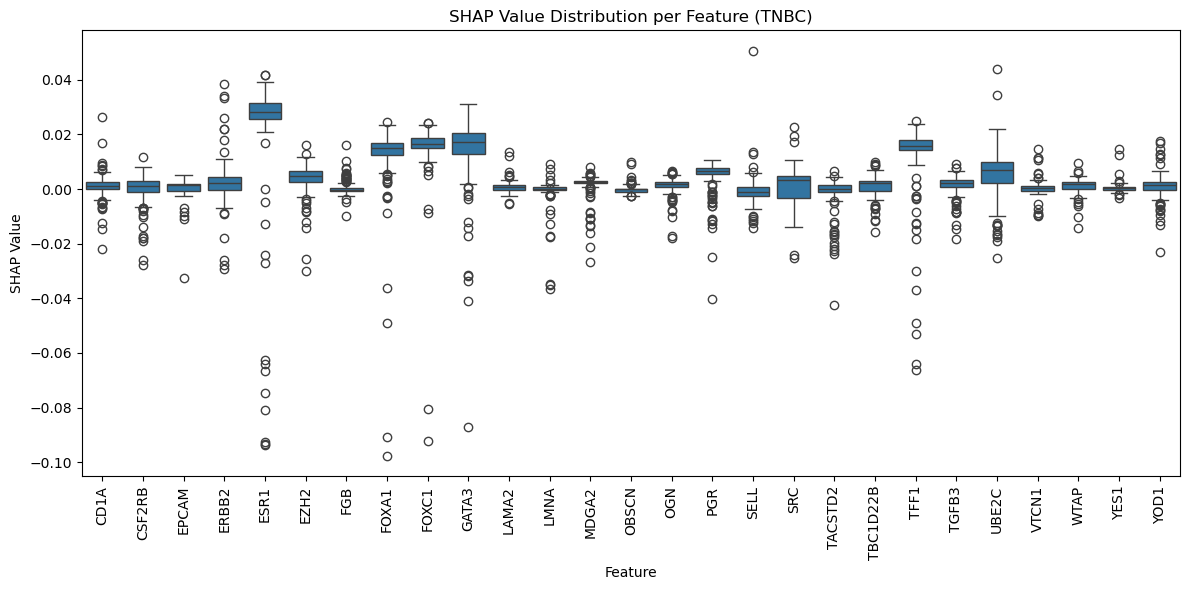

*** - Applying LG to LIME - Start
**********************************
*** DIT IS aantal -- 3
**********************************


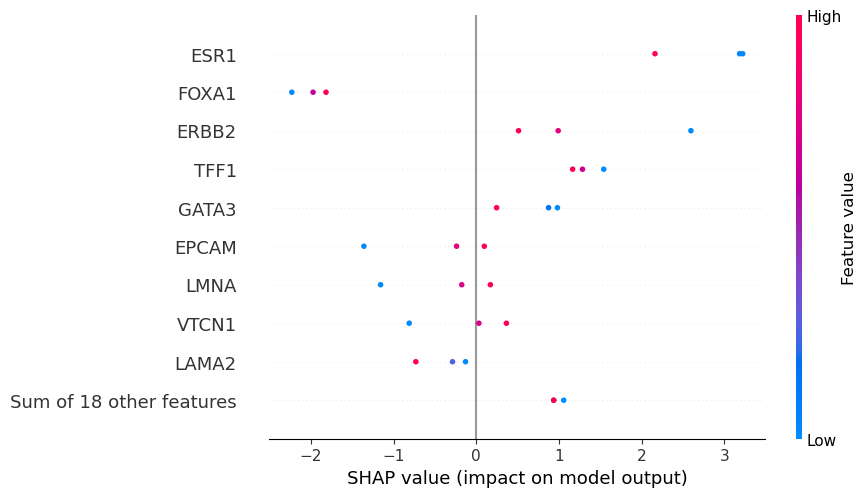

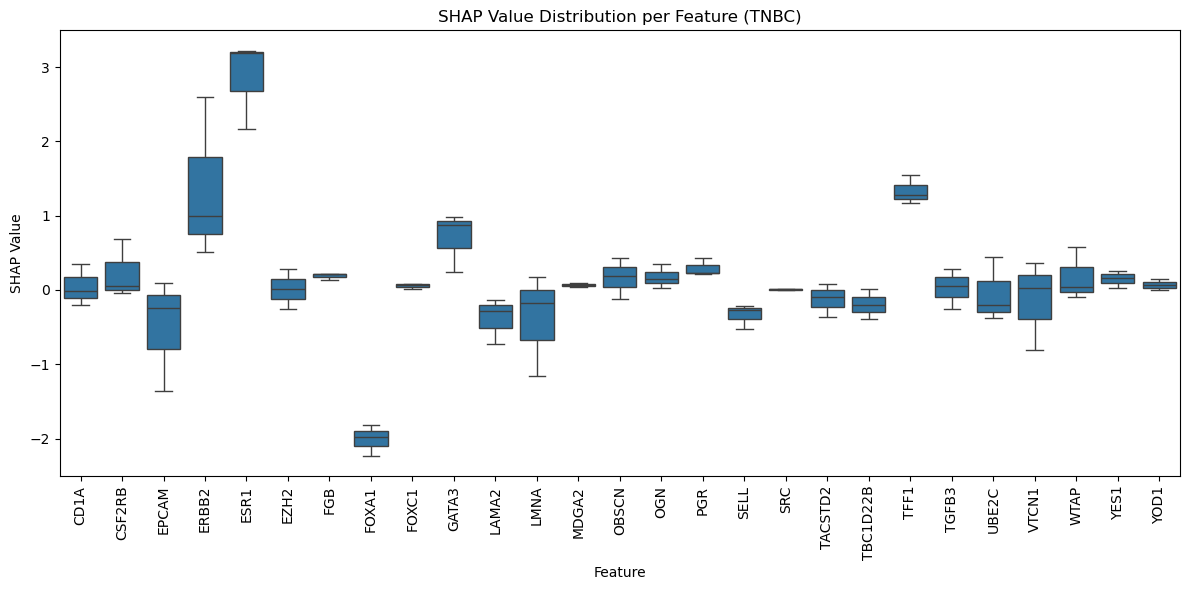

**********************************
*** DIT IS aantal -- 5
**********************************


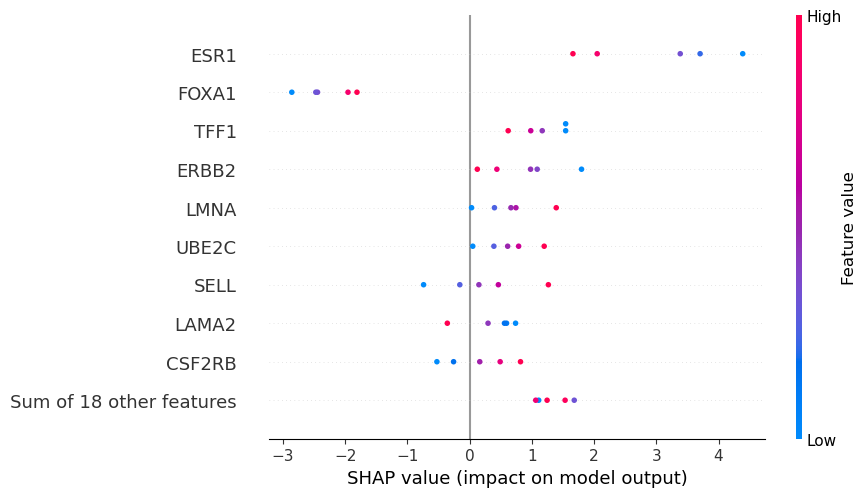

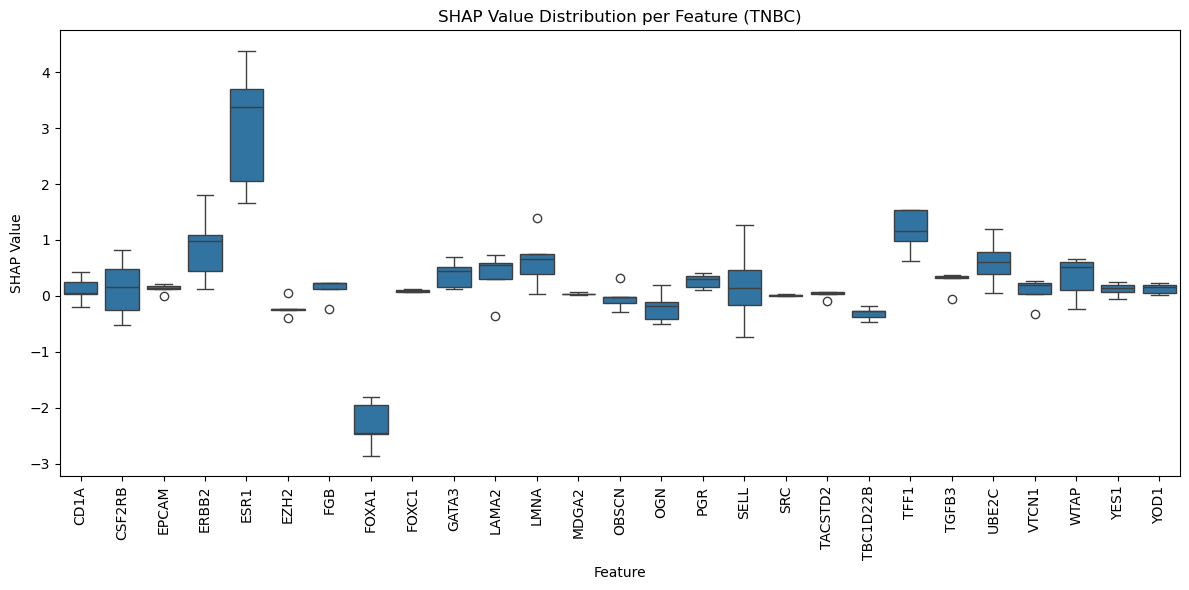

**********************************
*** DIT IS aantal -- 20
**********************************


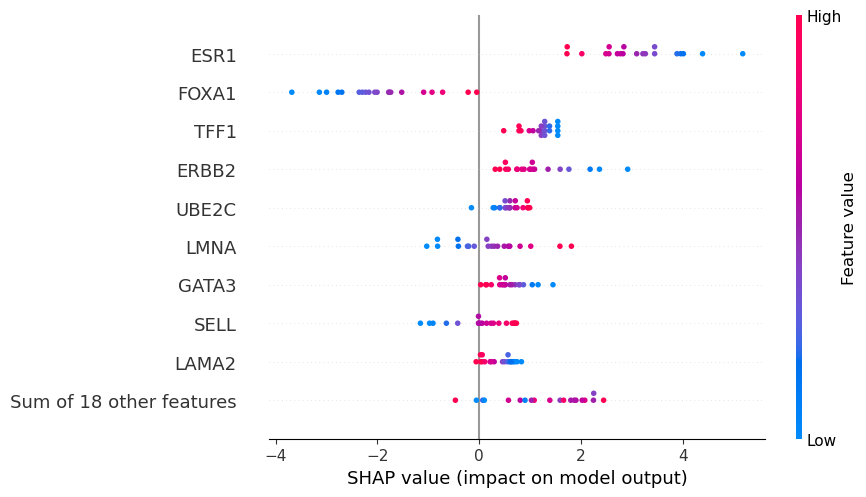

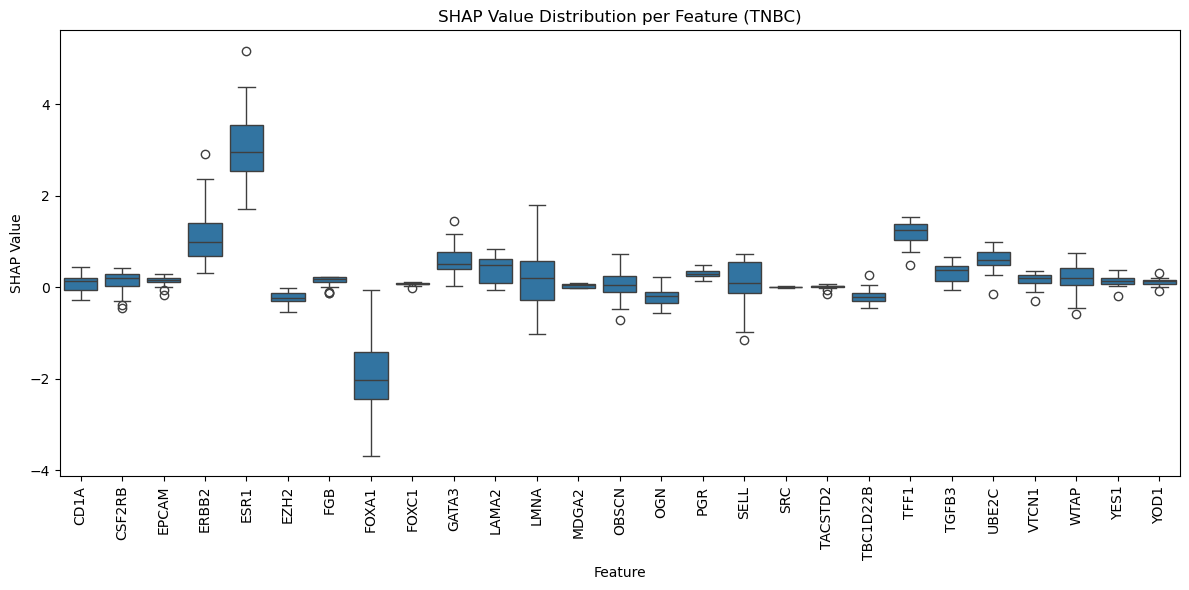

**********************************
*** DIT IS aantal -- 168
**********************************


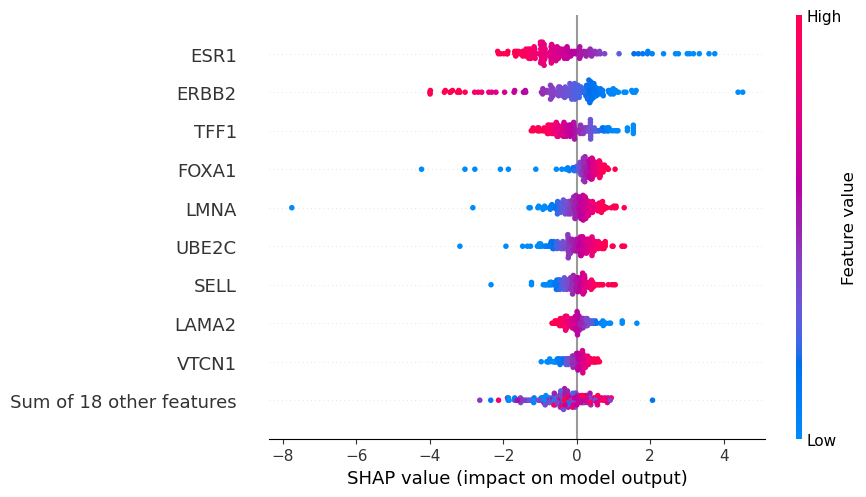

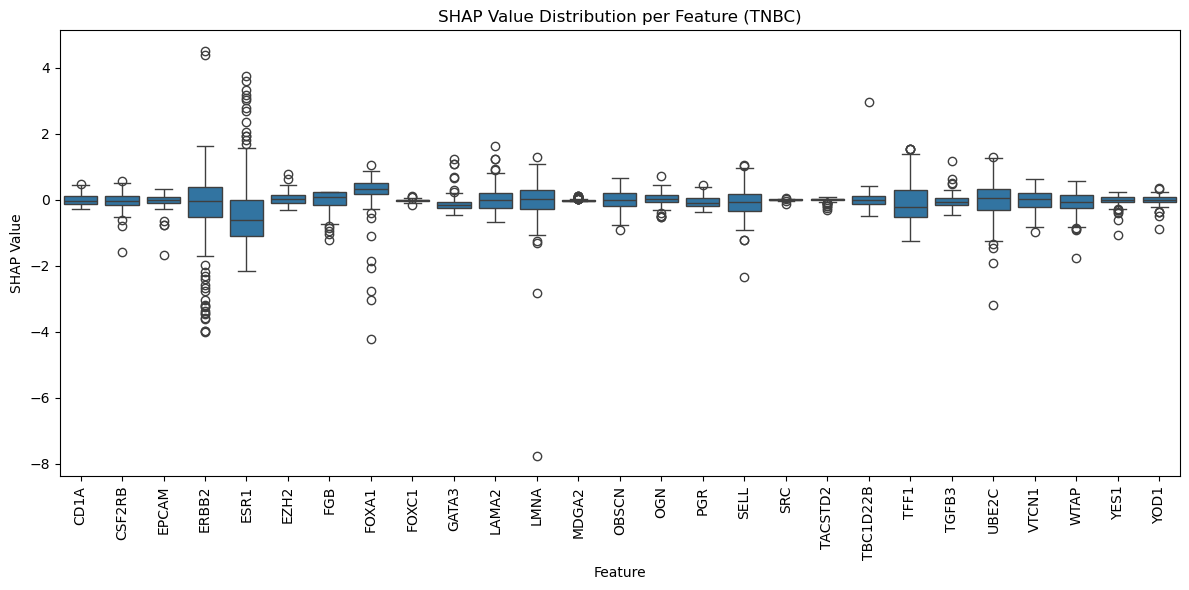

In [138]:
for modelName in ModelVariant.__members__:
    print(f'*** - Applying {modelName} to LIME - Start')
    model = getModel(modelName)

    model.fit(X_train.to_numpy(), y_train)

    if modelName == 'LG':
        maskerLG = shap.maskers.Independent(X_train)
        explainer = shap.LinearExplainer (model=model,                data=X_stratified, feature_names=targetGenes, masker=maskerLG)
    elif modelName == 'RF':
        explainer = shap.TreeExplainer   (model=model,                data=X_stratified, feature_names=targetGenes)
    else:
        explainer = shap.KernelExplainer (model=modelSVM.predict_proba, data=X_stratified, feature_names=targetGenes)


    # Ask SHAP for explanation
    shap_values = explainer(X_test) #new

    # Get confusion matrix
    y_pred = model.predict(np.array(X_test))
    y_test_series = pd.Series(y_test, index=X_test.index)  # preserve original indexes
    y_pred_series = pd.Series(y_pred, index=X_test.index)
    
    preds = pd.DataFrame({'real': y_test_series, 'model': y_pred_series})
    
    falseNegative = preds[(preds['real'] != preds['model']) & (preds['real'] == True)]
    falsePositive = preds[(preds['real'] != preds['model']) & (preds['real'] == False)]
    truePositive  = preds[(preds['real'] == preds['model']) & (preds['real'] == True)]
    trueNegative  = preds[(preds['real'] == preds['model']) & (preds['real'] == False)]
    alles = [falseNegative, falsePositive, truePositive, trueNegative]

    for iets in alles:
        print(f'**********************************')
        print(f'*** DIT IS aantal -- {len(iets)}')
        print(f'**********************************')
        iloc_positions = [preds.index.get_loc(i) for i in iets.index]
        rows = np.r_[iloc_positions]

        if modelName == 'LG':
            beeswarmChart = shap_values[rows, :]
            boxplotChart = shap_values.values[rows, :]
        if modelName == 'RF':
            beeswarmChart = shap_values[rows, :, 0]
            boxplotChart = shap_values.values[rows, :, 0]
        if modelName == 'SVM':
            beeswarmChart = shap_values[rows, :, 1]
            boxplotChart = shap_values.values[rows, :, 1]

        shap_df = pd.DataFrame(data=boxplotChart, columns=targetGenes)
        shap_melted = shap_df.melt(var_name='Feature', value_name='SHAP Value')

        # Melt the DataFrame for seaborn   
        shap.plots.beeswarm(beeswarmChart)
        
        # Plot
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=shap_melted, x='Feature', y='SHAP Value')
        plt.xticks(rotation=90)
        plt.title('SHAP Value Distribution per Feature (TNBC)')
        plt.tight_layout()
        plt.show()


In [51]:
iloc_positions = [preds.index.get_loc(i) for i in truePositive.index]

In [46]:
iloc_positions = [preds.index.get_loc(i) for i in trueNegative.index]

In [47]:
iloc_positions

[0,
 1,
 2,
 4,
 5,
 6,
 7,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 30,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 83,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 100,
 102,
 104,
 105,
 106,
 107,
 108,
 109,
 111,
 112,
 114,
 115,
 116,
 117,
 119,
 120,
 121,
 122,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 135,
 136,
 137,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 147,
 148,
 149,
 151,
 152,
 153,
 154,
 156,
 157,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 169,
 170,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 183,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 192,
 193,
 194,
 195]

In [29]:
falseNegative
falsePositive
truePositive 
trueNegative 

,real,model
145,False,False
36,False,False
635,False,False
46,False,False
224,False,False
...,...,...
518,False,False
113,False,False
4,False,False
832,False,False


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
kevintje = shap_values.values[rows, :, 1]
shap_df = pd.DataFrame(data=kevintje, columns=targetGenes)

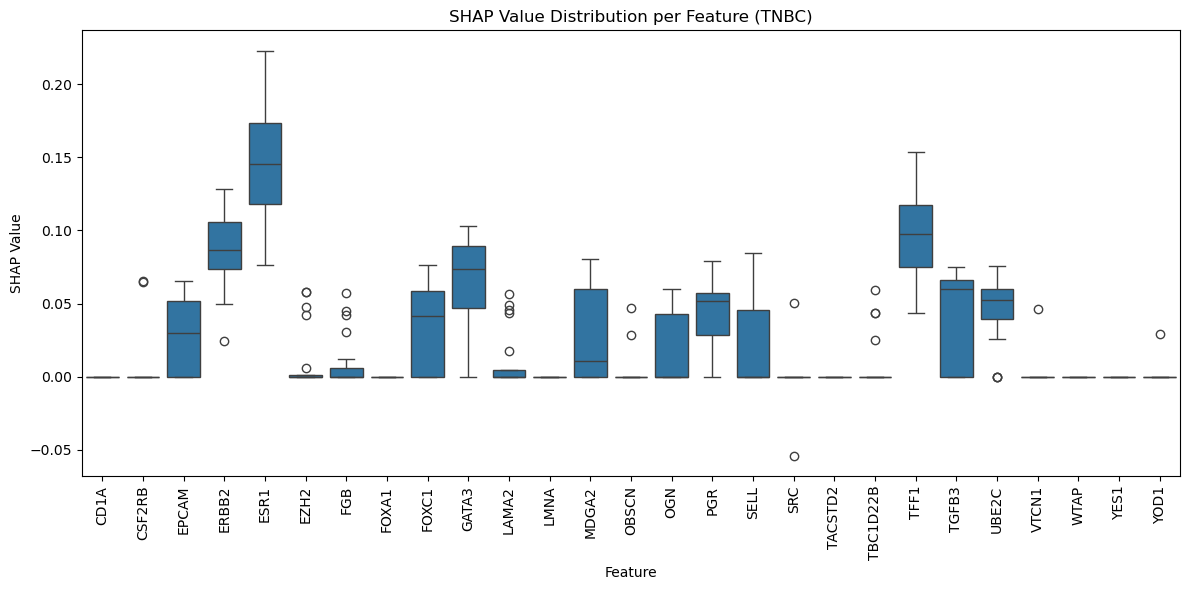

In [69]:
# Melt the DataFrame for seaborn
import seaborn as sns
shap_df = pd.DataFrame(data=kevintje, columns=targetGenes)
shap_melted = shap_df.melt(var_name='Feature', value_name='SHAP Value')

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=shap_melted, x='Feature', y='SHAP Value')
plt.xticks(rotation=90)
plt.title('SHAP Value Distribution per Feature (TNBC)')
plt.tight_layout()
plt.show()

In [93]:
modelName = 'RF'
print(f'*** - Applying {modelName} to LIME - Start')
model = getModel(modelName)

# Train the model
model.fit(X_train.to_numpy(), y_train)


*** - Applying RF to LIME - Start


RandomForestClassifier(random_state=42)

In [94]:

#########################
# SHAP
#
# Get explainer
#########################
explainer = shap.TreeExplainer(model=model, data=X_stratified, feature_names=targetGenes)

#########################
# SHAP
#
# Get results 
#########################
shap_values = explainer(X_test) #new



In [95]:
#shap_values

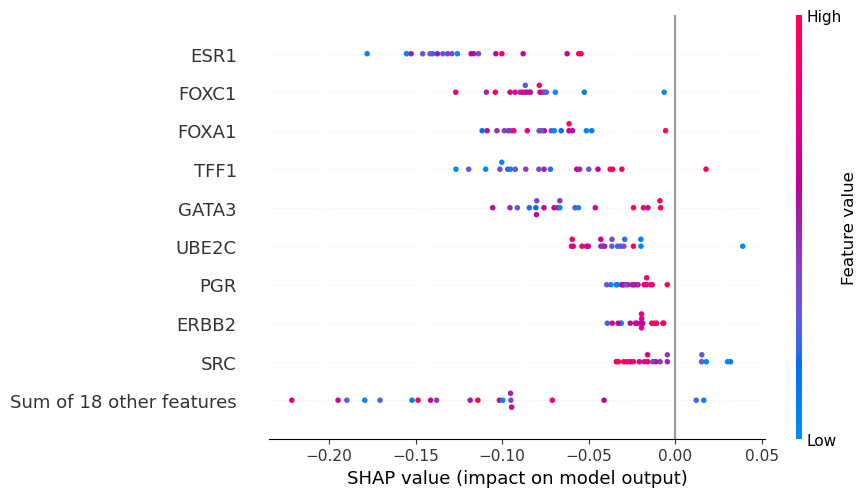

In [98]:
shap.plots.beeswarm(shap_values[rows, :, 0])

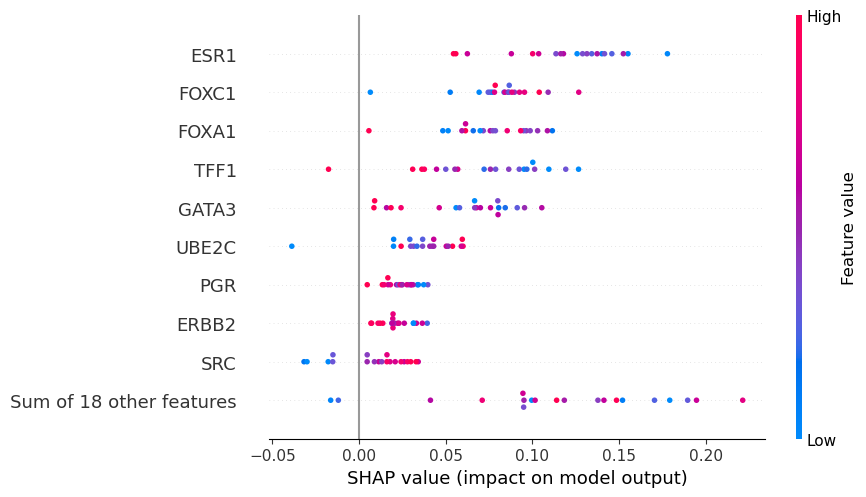

In [99]:
shap.plots.beeswarm(shap_values[rows, :, 1])